# Results and Discussion

## 0. Academic Paper Visualization Standards
For future plots, diagrams, and illustrations in this notebook, please adhere to the following academic standards:
- **Font & Text**: Use clear, legible fonts (e.g., serif for print, sans-serif like Helvetica for presentations). Font sizes should be large enough to be legible when scaled down (typically at least 10pt-12pt).
- **Colors**: Use colorblind-friendly palettes (e.g., Viridis, colorblind-safe seaborn palettes). Ensure high contrast between elements. Use greyscale or patterns where color is not strictly necessary.
- **Axes & Labels**: All axes must be clearly labeled with units. Titles should be concise. Include a legend if multiple data series are plotted.
- **Resolution**: Save all figures as high-resolution images (minimum 300 DPI for PNG/JPEG) or vector graphics (PDF/SVG) for lossless scaling.
- **Layout**: Keep whitespace minimal but sufficient. For side-by-side comparisons, ensure subplots share the same scale if directly comparable, and use clear panel labels (e.g., (a), (b)).

## 1. Environment and Demand

### Arterial Pruning

In [1]:
import os
import sys
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('.'))
from utils_simplified import build_citygraph, reuse_citygraph

# PATHS FOR OUTPUTS
BASE_DIR = 'results_and_discussion'
PKL_DIR = os.path.join(BASE_DIR, 'pkl')
IMG_DIR = os.path.join(BASE_DIR, 'images')

os.makedirs(PKL_DIR, exist_ok=True)
os.makedirs(IMG_DIR, exist_ok=True)

print(f"Pickle files saved in: {PKL_DIR}")
print(f"Images saved in: {IMG_DIR}")

Pickle files saved in: results_and_discussion\pkl
Images saved in: results_and_discussion\images


In [3]:
# Configuration for P1 (Which has the Iligan Graph. All profiles share the same coordinates anyway.)

yaml_p1 = "configs/profile_p1.yaml"
pkl_p1 = os.path.join(PKL_DIR, "profile_p1.pkl")

# Reuse existing pkl if exists, otherwise build.

try:
    cg = reuse_citygraph(pkl_p1)
except FileNotFoundError:
    cg = build_citygraph(yaml_p1, pkl_p1)

print(cg)

[INFO] Reusing CityGraph from pickle file: results_and_discussion\pkl\profile_p1.pkl
CityGraph(Iligan City) | Nodes: 36866 | Edges: 76310 (Drivable: 26024) | Landmarks: ['MSU-IIT', 'Robinsons Place']


Generated in previous run already. File found. Now displaying.


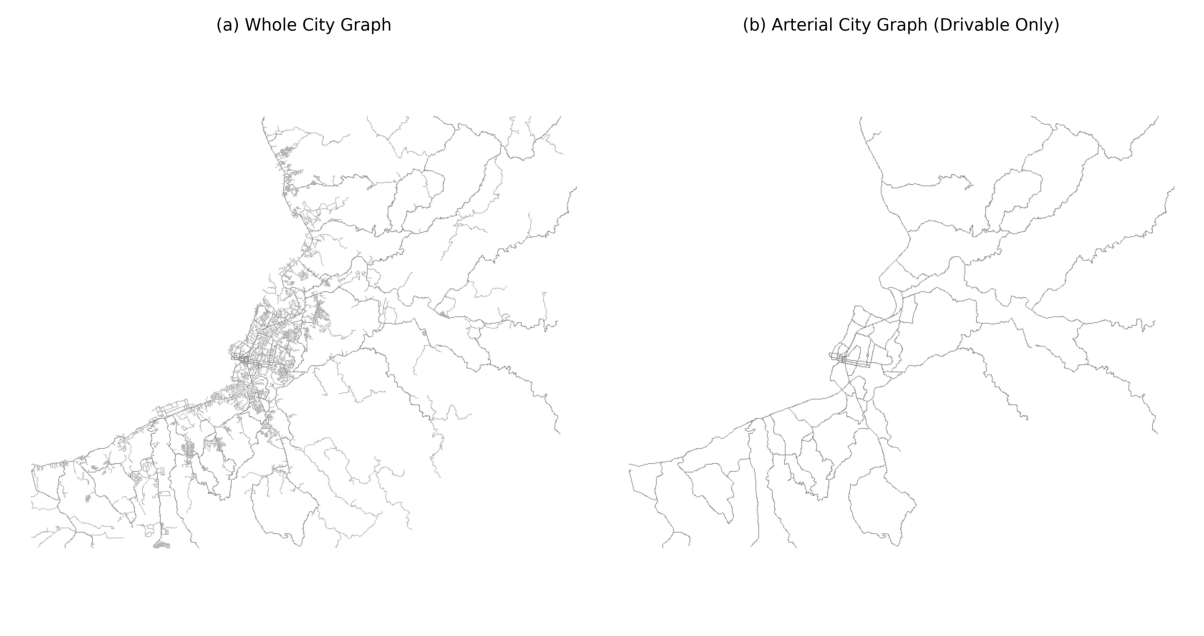

In [4]:
import os
import matplotlib.pyplot as plt

out_path = os.path.join(IMG_DIR, "citygraph_comparison.png")

if os.path.exists(out_path):
    print(f"Generated in previous run already. File found. Now displaying.")

    img = plt.imread(out_path)
    plt.figure(figsize=(16, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.show()
else:
    print("Rendering whole city graph...")
    img_whole = cg.draw(size=800, only_drivable=False)

    print("Rendering arterial city graph...")
    img_arterial = cg.draw(size=800, only_drivable=True)

    # Plot side by side
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    axes[0].imshow(img_whole)
    axes[0].set_title("(a) Whole City Graph", fontsize=16, pad=15)
    axes[0].axis('off')

    axes[1].imshow(img_arterial)
    axes[1].set_title("(b) Arterial City Graph (Drivable Only)", fontsize=16, pad=15)
    axes[1].axis('off')

    plt.tight_layout()

    # Save the figure
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    print(f"Saved new figure to {out_path}")

    plt.show()
